In [9]:
!pip install networkx
!pip install osmnx

In [15]:
import geopandas as gpd
import osmnx as ox
import numpy as np
import networkx as nx
from scipy.spatial import Voronoi, voronoi_plot_2d
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import json
from pathlib import Path

ox.settings.use_cache = True
ox.settings.log_console = True

# the warnings are too annoying 
import warnings
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered",
    category=RuntimeWarning
)
warnings.filterwarnings(
    "ignore",
    category=UserWarning
)

bornholm


/var/folders/vy/l49fzb3j41b_bvyvsvdcjwb40000gn/T/ipykernel_20184/3164717526.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  place_poly = place_gdf.geometry.unary_union


Graph CRS: EPSG:32633
<class 'networkx.classes.multidigraph.MultiDiGraph'>
 Directed: True


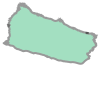

In [16]:
sample = "bornholm"

print (sample)
# Extract polygon of sample municipality
place_gdf = ox.geocode_to_gdf(sample)
place_poly = place_gdf.geometry.unary_union

### GRAPH ###
# Make bike network graph for sample
G = ox.graph_from_place(sample, network_type='bike', retain_all=True) #add simplify=True
G_proj = ox.project_graph(G)
graph_crs = G_proj.graph["crs"]

print ("Graph CRS:", graph_crs)
print(type(G_proj))
print(" Directed:", G_proj.is_directed())

place_gdf.geometry.iloc[0]

bornholm


/var/folders/vy/l49fzb3j41b_bvyvsvdcjwb40000gn/T/ipykernel_20184/2241632554.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  place_poly = place_gdf.geometry.unary_union


<class 'networkx.classes.multidigraph.MultiDiGraph'>
 Directed: True


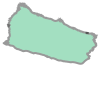

In [17]:
sample = "bornholm"

print (sample)
# Extract polygon of sample municipality
place_gdf = ox.geocode_to_gdf(sample)
place_poly = place_gdf.geometry.unary_union

### GRAPH ###
# Make bike network graph for sample
G = ox.graph_from_place(sample, network_type='bike', retain_all=True) #add simplify=True
G_proj = ox.project_graph(G)
graph_crs = G_proj.graph["crs"]
print(type(G_proj))
print(" Directed:", G_proj.is_directed())

place_gdf.geometry.iloc[0]

In [18]:
PLACE = "Bornholm, Denmark"

sample = "Bornholm, Denmark"
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

print(sample)

Bornholm, Denmark


In [19]:
place_gdf = ox.geocode_to_gdf(sample)
place_poly = place_gdf.geometry.union_all()

place_gdf

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"MULTIPOLYGON (((14.67571 55.09425, 14.67573 55...",14.675709,54.987239,15.156922,55.299121,147084819,relation,5176019,55.143122,14.92263,place,island,17,0.592547,island,Bornholm,"Bornholm, Capital Region of Denmark, Denmark"


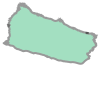

In [20]:
# Display the boundary geometry.
place_gdf.geometry.iloc[0]

In [21]:
# retain_all=True keeps disconnected bike-accessible components.
G = ox.graph_from_polygon(
    place_poly,
    network_type="bike",
    retain_all=True,
    simplify=True,
)

G_proj = ox.project_graph(G)
graph_crs = G_proj.graph["crs"]

print(type(G_proj))
print("Directed:", G_proj.is_directed())
print("CRS:", graph_crs)
print("Nodes:", G_proj.number_of_nodes())
print("Edges:", G_proj.number_of_edges())

<class 'networkx.classes.multidigraph.MultiDiGraph'>
Directed: True
CRS: EPSG:32633
Nodes: 26330
Edges: 61331


In [22]:
graph_path = output_dir / "bornholm_bike_network.graphml"
boundary_path = output_dir / "bornholm_boundary.geojson"

ox.io.save_graphml(G_proj, graph_path)
place_gdf.to_file(boundary_path, driver="GeoJSON")

print("Saved graph to:", graph_path)
print("Saved boundary to:", boundary_path)

Saved graph to: outputs/bornholm_bike_network.graphml
Saved boundary to: outputs/bornholm_boundary.geojson


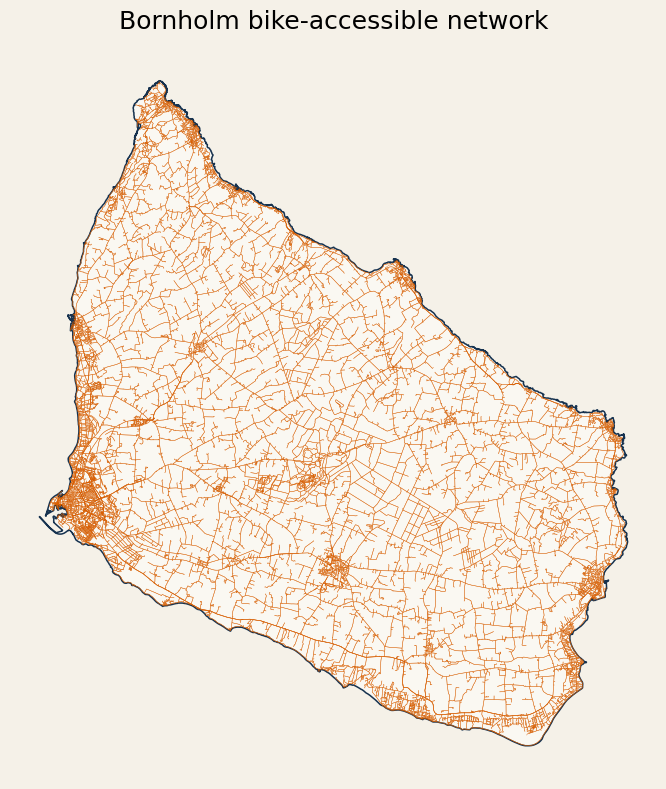

Saved plot to: outputs/bornholm_bike_network.png


In [23]:
boundary_proj = place_gdf.to_crs(graph_crs)
nodes, edges = ox.graph_to_gdfs(G_proj)

fig, ax = plt.subplots(figsize=(10, 8), facecolor="#f5f1e8")

boundary_proj.plot(
    ax=ax,
    facecolor="#faf8f2",
    edgecolor="#16324f",
    linewidth=1.1,
    zorder=1,
)

edges.plot(
    ax=ax,
    color="#d95f02",
    linewidth=0.32,
    alpha=0.82,
    zorder=2,
)

ax.set_title("Bornholm bike-accessible network", fontsize=18, pad=14)
ax.set_axis_off()
fig.tight_layout()

plot_path = output_dir / "bornholm_bike_network.png"
fig.savefig(plot_path, dpi=240, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved plot to:", plot_path)

# Bornholm network overlap analysis

Compare the processed BikeNodePlanner / knudepunkter network with the OpenStreetMap bike-accessible network for Bornholm.

The notebook measures overlap in both directions:
- Study coverage by OSM: percentage of the unique knudepunkter line length lying within a given distance of an OSM bike-accessible line.
- OSM coverage by the study network: percentage of the unique OSM bike-network length lying within a given distance of a knudepunkter line.
- Node proximity: percentage of knudepunkter nodes within each distance threshold of OSM linework.
Several tolerances are reported because independently digitized lines rarely coincide exactly. A 20 m tolerance is used for the detailed map and link classification; adjust it below if needed.

The processed study file stores Bornholm translated 220 km west and 120 km north for the source project's combined Denmark maps. This notebook reverses that translation before comparison.

In [24]:
# Run once if these packages are not already installed.
%pip install osmnx python-igraph geopandas matplotlib pandas shapely

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 16.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: igraph
    Found existing installation: igraph 0.11.5
    Uninstalling igraph-0.11.5:
      Successfully uninstalled igraph-0.11.5
Note: you may need to restart the kernel to use updated packages.


In [26]:
from pathlib import Path
import lzma
import pickle

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import pandas as pd
import shapely
from IPython.display import display
from shapely.geometry import Point

STUDY_GRAPH_PATH = Path(
    "/Users/ellenebdrup/Documents/GitHub/bike_safety/"
    "bikenwloops/data/processed/bornholm/network_preprocessed0.xz"
)

# This is the GraphML created by the earlier Bornholm OSMnx notebook.
# If it is absent, the next section downloads the network again.
OSM_GRAPH_PATH = Path(
    "/Users/ellenebdrup/Documents/Codex/2026-09-11/loa/"
    "outputs/bornholm_bike_network.graphml"
)

OUTPUT_DIR = Path("outputs/overlap_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STUDY_CRS = "EPSG:25832"  # CRS used by the bikenwloops study
TOLERANCES_M = [5, 10, 20, 30, 50]
DETAIL_TOLERANCE_M = 20

# The bikenwloops preprocessing applied this offset to Bornholm for plotting.
# It must be reversed to restore Bornholm's real EPSG:25832 position.
STUDY_STORED_OFFSET_M = (-220_000, 120_000)
UNDO_STUDY_OFFSET = True

assert STUDY_GRAPH_PATH.exists(), f"Study graph not found: {STUDY_GRAPH_PATH}"
print("Study graph:", STUDY_GRAPH_PATH)
print("OSM graph exists:", OSM_GRAPH_PATH.exists())
print("Results folder:", OUTPUT_DIR.resolve())

Study graph: /Users/ellenebdrup/Documents/GitHub/bike_safety/bikenwloops/data/processed/bornholm/network_preprocessed0.xz
OSM graph exists: True
Results folder: /Users/ellenebdrup/Documents/GitHub/bike_safety/osm_data_exploration/outputs/overlap_analysis


In [27]:
with lzma.open(STUDY_GRAPH_PATH, "rb") as file:
    study_graph = pickle.load(file)

print(study_graph.summary())
print("Directed:", study_graph.is_directed())
print("Vertex attributes:", study_graph.vs.attribute_names())
print("Edge attributes:", study_graph.es.attribute_names())

IGRAPH UNW- 59 89 -- 
+ attr: id_cykelknudepkt (v), name (v), x (v), y (v), edge_id (e), geometry (e), max_slope (e), weight (e)
Directed: False
Vertex attributes: ['name', 'id_cykelknudepkt', 'x', 'y']
Edge attributes: ['weight', 'edge_id', 'max_slope', 'geometry']


In [28]:
# Convert igraph vertices and edges to GeoDataFrames.
node_records = []
for vertex in study_graph.vs:
    attrs = vertex.attributes().copy()
    attrs["igraph_index"] = vertex.index
    attrs["geometry"] = Point(attrs["x"], attrs["y"])
    node_records.append(attrs)

edge_records = []
for edge in study_graph.es:
    attrs = edge.attributes().copy()
    attrs["source"], attrs["target"] = edge.tuple
    edge_records.append(attrs)

study_nodes = gpd.GeoDataFrame(node_records, geometry="geometry", crs=STUDY_CRS)
study_edges = gpd.GeoDataFrame(edge_records, geometry="geometry", crs=STUDY_CRS)
study_edges = study_edges.loc[
    study_edges.geometry.notna() & ~study_edges.geometry.is_empty
].copy()

if UNDO_STUDY_OFFSET:
    undo_x = -STUDY_STORED_OFFSET_M[0]
    undo_y = -STUDY_STORED_OFFSET_M[1]
    study_nodes["geometry"] = study_nodes.geometry.translate(xoff=undo_x, yoff=undo_y)
    study_edges["geometry"] = study_edges.geometry.translate(xoff=undo_x, yoff=undo_y)
    study_nodes["x"] = study_nodes.geometry.x
    study_nodes["y"] = study_nodes.geometry.y
    print(f"Reversed stored Bornholm offset: x {undo_x:+,} m, y {undo_y:+,} m")

print(f"Study nodes: {len(study_nodes):,}")
print(f"Study links: {len(study_edges):,}")
print("Study CRS:", study_edges.crs)
display(study_edges.head(3))

Reversed stored Bornholm offset: x +220,000 m, y -120,000 m
Study nodes: 59
Study links: 89
Study CRS: EPSG:25832


,weight,edge_id,max_slope,geometry,source,target
0,4070.941878,0,3.750957,"LINESTRING (884790.176 6111667.992, 884809.13 ...",0,1
1,5059.992235,1,4.673647,"LINESTRING (881658.93 6114106.8, 881668.7 6114...",0,2
2,3526.484593,2,4.319620,"LINESTRING (884790.176 6111667.992, 884790.75 ...",0,3


In [29]:
if OSM_GRAPH_PATH.exists():
    G_osm = ox.load_graphml(OSM_GRAPH_PATH)
    print("Loaded the existing OSM GraphML file.")
else:
    print("OSM GraphML not found; downloading Bornholm from OpenStreetMap...")
    G_osm = ox.graph_from_place(
        "Bornholm, Denmark",
        network_type="bike",
        retain_all=True,
        simplify=True,
    )
    G_osm = ox.project_graph(G_osm)
    OSM_GRAPH_PATH.parent.mkdir(parents=True, exist_ok=True)
    ox.save_graphml(G_osm, OSM_GRAPH_PATH)

osm_nodes, osm_edges = ox.graph_to_gdfs(G_osm)

# Put both datasets in the study's metre-based CRS.
osm_nodes = osm_nodes.to_crs(STUDY_CRS)
osm_edges = osm_edges.to_crs(STUDY_CRS)

print(type(G_osm))
print("Directed:", G_osm.is_directed())
print(f"OSM nodes: {len(osm_nodes):,}")
print(f"OSM directed edges: {len(osm_edges):,}")
print("Analysis CRS:", osm_edges.crs)

Loaded the existing OSM GraphML file.
<class 'networkx.classes.multidigraph.MultiDiGraph'>
Directed: True
OSM nodes: 26,330
OSM directed edges: 61,331
Analysis CRS: EPSG:25832


### 4. Create unique physical line networks
OSMnx represents bicycle travel as a directed graph, so the same physical line can appear once in each direction. Dissolving the geometries prevents those duplicates from inflating the length totals. The study linework is dissolved for the same reason.

In [30]:
study_network = shapely.union_all(study_edges.geometry.array)
osm_network = shapely.union_all(osm_edges.geometry.array)

study_length_m = study_network.length
osm_length_m = osm_network.length

network_summary = pd.DataFrame(
    {
        "network": ["Knudepunkter study network", "OSM bike-accessible network"],
        "unique_length_km": [study_length_m / 1000, osm_length_m / 1000],
        "nodes": [len(study_nodes), len(osm_nodes)],
        "stored_edges": [len(study_edges), len(osm_edges)],
    }
)
display(network_summary.round(2))

,network,unique_length_km,nodes,stored_edges
0,Knudepunkter study network,375.73,59,89
1,OSM bike-accessible network,3100.08,26330,61331


### 5. Calculate length and node overlap across tolerances
For each tolerance, the notebook buffers one network and measures how much of the other network falls inside that buffer. This is a line-coverage measure, not merely a bounding-box intersection.

In [31]:
# Use spatial indexes so the full-island comparison remains fast.
nearest_node_matches = gpd.sjoin_nearest(
    study_nodes[["geometry"]],
    osm_edges[["geometry"]],
    how="left",
    distance_col="distance_to_osm_m",
)
study_nodes["distance_to_osm_m"] = (
    nearest_node_matches.groupby(level=0)["distance_to_osm_m"].min()
)

# Only OSM edges close enough to possibly overlap the study network are
# needed for the numerators. The denominator still uses all OSM linework.
maximum_buffer = study_network.buffer(max(TOLERANCES_M))
candidate_positions = osm_edges.sindex.query(maximum_buffer, predicate="intersects")
osm_edges_near_study = osm_edges.iloc[np.unique(candidate_positions)].copy()
osm_near_study_network = shapely.union_all(osm_edges_near_study.geometry.array)
print(f"OSM edges close enough to compare: {len(osm_edges_near_study):,}")

overlap_rows = []
for tolerance_m in TOLERANCES_M:
    osm_buffer = osm_near_study_network.buffer(tolerance_m)
    study_buffer = study_network.buffer(tolerance_m)

    study_covered_m = study_network.intersection(osm_buffer).length
    osm_covered_m = osm_near_study_network.intersection(study_buffer).length
    nodes_covered = int((study_nodes["distance_to_osm_m"] <= tolerance_m).sum())

    overlap_rows.append(
        {
            "tolerance_m": tolerance_m,
            "study_covered_km": study_covered_m / 1000,
            "study_coverage_pct": 100 * study_covered_m / study_length_m,
            "osm_covered_km": osm_covered_m / 1000,
            "osm_coverage_pct": 100 * osm_covered_m / osm_length_m,
            "study_nodes_near_osm": nodes_covered,
            "study_node_coverage_pct": 100 * nodes_covered / len(study_nodes),
        }
    )

overlap = pd.DataFrame(overlap_rows)
overlap.to_csv(OUTPUT_DIR / "overlap_by_tolerance.csv", index=False)
display(overlap.round(2))

OSM edges close enough to compare: 16,352


,tolerance_m,study_covered_km,study_coverage_pct,osm_covered_km,osm_coverage_pct,study_nodes_near_osm,study_node_coverage_pct
0,5,369.60,98.37,398.15,12.84,56,94.92
1,10,374.35,99.63,490.78,15.83,57,96.61
2,20,374.81,99.76,536.34,17.30,59,100.00
3,30,375.06,99.82,576.03,18.58,59,100.00
4,50,375.29,99.88,655.06,21.13,59,100.00


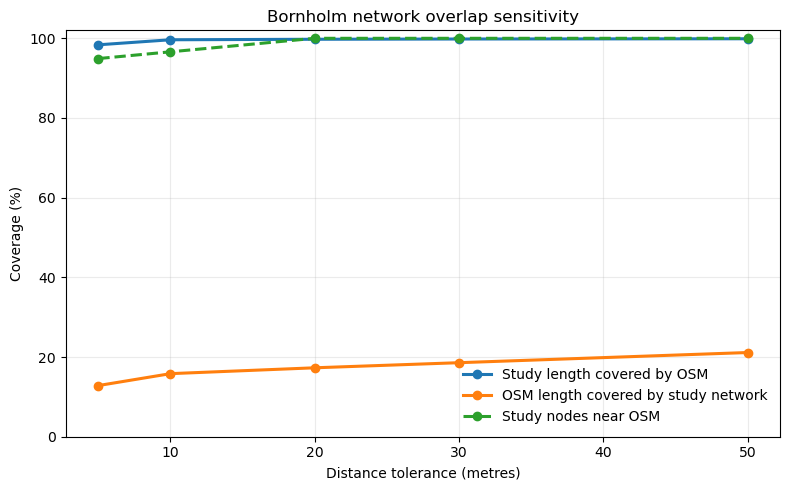

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    overlap["tolerance_m"],
    overlap["study_coverage_pct"],
    marker="o",
    linewidth=2.2,
    label="Study length covered by OSM",
)
ax.plot(
    overlap["tolerance_m"],
    overlap["osm_coverage_pct"],
    marker="o",
    linewidth=2.2,
    label="OSM length covered by study network",
)
ax.plot(
    overlap["tolerance_m"],
    overlap["study_node_coverage_pct"],
    marker="o",
    linewidth=2.2,
    linestyle="--",
    label="Study nodes near OSM",
)
ax.set(
    xlabel="Distance tolerance (metres)",
    ylabel="Coverage (%)",
    title="Bornholm network overlap sensitivity",
    ylim=(0, 102),
)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "overlap_by_tolerance.png", dpi=220, bbox_inches="tight")
plt.show()

### 6. Classify every study link at the detailed tolerance
Links are classified by the share of their length lying within the selected OSM buffer:
- Matched: at least 90%
- Partial: 10% to less than 90%
- Unmatched: less than 10%

In [33]:
osm_detail_buffer = osm_near_study_network.buffer(DETAIL_TOLERANCE_M)

study_edges["link_length_m"] = study_edges.geometry.length
study_edges["covered_length_m"] = study_edges.geometry.apply(
    lambda geom: geom.intersection(osm_detail_buffer).length
)
study_edges["coverage_pct"] = np.where(
    study_edges["link_length_m"] > 0,
    100 * study_edges["covered_length_m"] / study_edges["link_length_m"],
    np.nan,
)
study_edges["overlap_class"] = pd.cut(
    study_edges["coverage_pct"],
    bins=[-np.inf, 10, 90, np.inf],
    labels=["Unmatched (<10%)", "Partial (10–<90%)", "Matched (≥90%)"],
    right=False,
)

link_summary = (
    study_edges.groupby("overlap_class", observed=False)
    .agg(
        links=("edge_id", "count"),
        total_link_km=("link_length_m", lambda values: values.sum() / 1000),
        mean_coverage_pct=("coverage_pct", "mean"),
    )
    .reset_index()
)
study_edges.to_file(OUTPUT_DIR / "study_link_overlap.gpkg", layer="links", driver="GPKG")
link_summary.to_csv(OUTPUT_DIR / "study_link_overlap_summary.csv", index=False)
display(link_summary.round(2))

,overlap_class,links,total_link_km,mean_coverage_pct
0,Unmatched (<10%),0,0.00,NaN
1,Partial (10–<90%),0,0.00,NaN
2,Matched (≥90%),89,375.73,99.87


### 7. Map matched and unmatched portions
Green shows study-network linework within the selected distance of OSM. Red shows study-network linework outside it. The full OSM bike-accessible network is shown in light grey for context.

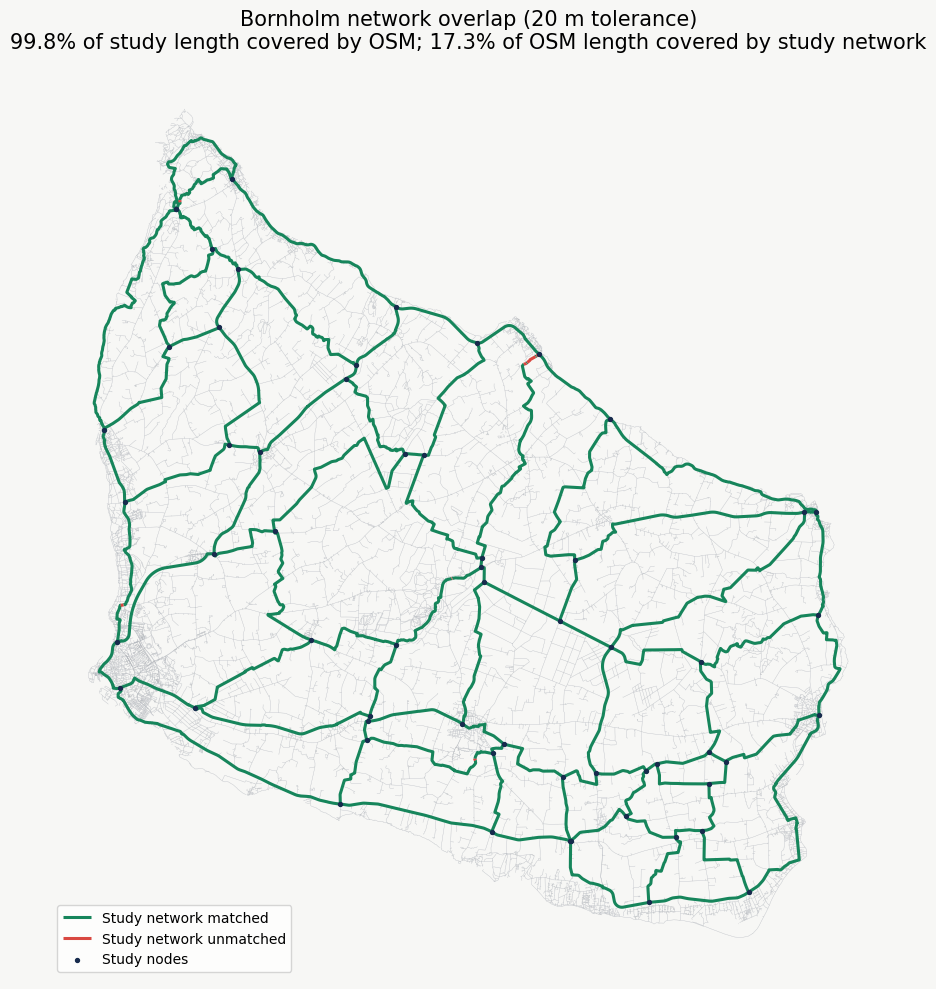

In [34]:
matched_geometry = study_network.intersection(osm_detail_buffer)
unmatched_geometry = study_network.difference(osm_detail_buffer)

matched_gs = gpd.GeoSeries([matched_geometry], crs=STUDY_CRS)
unmatched_gs = gpd.GeoSeries([unmatched_geometry], crs=STUDY_CRS)

detail_row = overlap.loc[overlap["tolerance_m"] == DETAIL_TOLERANCE_M].iloc[0]

fig, ax = plt.subplots(figsize=(11, 10), facecolor="#f7f7f5")
osm_edges.plot(ax=ax, color="#b8bcc2", linewidth=0.25, alpha=0.55, zorder=1)
matched_gs.plot(ax=ax, color="#16855b", linewidth=2.2, zorder=3, label="Study network matched")
if not unmatched_geometry.is_empty:
    unmatched_gs.plot(ax=ax, color="#d94841", linewidth=2.2, zorder=4, label="Study network unmatched")
study_nodes.plot(ax=ax, color="#172b4d", markersize=8, zorder=5, label="Study nodes")

ax.set_title(
    f"Bornholm network overlap ({DETAIL_TOLERANCE_M} m tolerance)\n"
    f"{detail_row['study_coverage_pct']:.1f}% of study length covered by OSM; "
    f"{detail_row['osm_coverage_pct']:.1f}% of OSM length covered by study network",
    fontsize=15,
    pad=14,
)
ax.legend(frameon=True, loc="lower left")
ax.set_axis_off()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "bornholm_network_overlap_map.png", dpi=240, bbox_inches="tight")
plt.show()

In [35]:
link_columns = [
    column
    for column in ["edge_id", "source", "target", "link_length_m", "coverage_pct", "overlap_class"]
    if column in study_edges.columns
]
lowest_coverage_links = study_edges[link_columns].sort_values("coverage_pct").head(20)
farthest_nodes = (
    study_nodes.drop(columns="geometry")
    .sort_values("distance_to_osm_m", ascending=False)
    .head(20)
)

lowest_coverage_links.to_csv(OUTPUT_DIR / "lowest_coverage_links.csv", index=False)
farthest_nodes.to_csv(OUTPUT_DIR / "farthest_nodes_from_osm.csv", index=False)

print("Study links with the lowest OSM coverage:")
display(lowest_coverage_links.round(2))
print("Study nodes farthest from OSM linework:")
display(farthest_nodes.round(2))

Study links with the lowest OSM coverage:


,edge_id,source,target,link_length_m,coverage_pct,overlap_class
65,65,40,47,10499.53,94.03,Matched (≥90%)
88,88,57,58,3707.19,97.76,Matched (≥90%)
46,49,27,37,6263.73,98.23,Matched (≥90%)
23,25,12,14,6357.48,98.86,Matched (≥90%)
51,46,30,34,5389.03,99.55,Matched (≥90%)
41,37,23,29,199.67,100.00,Matched (≥90%)
40,35,23,24,3919.85,100.00,Matched (≥90%)
66,68,41,44,1356.35,100.00,Matched (≥90%)
17,19,9,18,2787.06,100.00,Matched (≥90%)
14,12,7,11,6181.67,100.00,Matched (≥90%)


Study nodes farthest from OSM linework:


,name,id_cykelknudepkt,x,y,igraph_index,distance_to_osm_m
27,29,"['vk2551', 'vk2552', 'vk2550']",863655.06,6122019.88,27,11.60
15,20,"['vk2571', 'vk2570', 'vk2569', 'vk2568', 'vk28...",863748.46,6120201.90,15,11.28
41,42,"['vk2819', 'vk2572', 'vk2573', 'vk2818']",869333.55,6129581.46,41,6.58
28,31,['vk2561'],878246.97,6124408.01,28,3.58
42,43,"['vk2841', 'vk2842', 'vk2843', 'vk2608', 'vk26...",883259.94,6130890.32,42,1.94
49,48,['vk2540'],872750.04,6132500.24,49,1.31
4,4,['vk2755'],886896.12,6114528.37,4,1.20
14,17,['vk2596'],873572.39,6118111.61,14,1.01
45,46,"['vk2576', 'vk4555', 'vk4557']",863127.25,6130453.51,45,0.87
31,28,['vk2582'],871357.39,6122102.89,31,0.86


IGRAPH UNW- 59 89 -- 
+ attr: id_cykelknudepkt (v), name (v), x (v), y (v), edge_id (e), geometry (e), max_slope (e), weight (e)
Directed: False


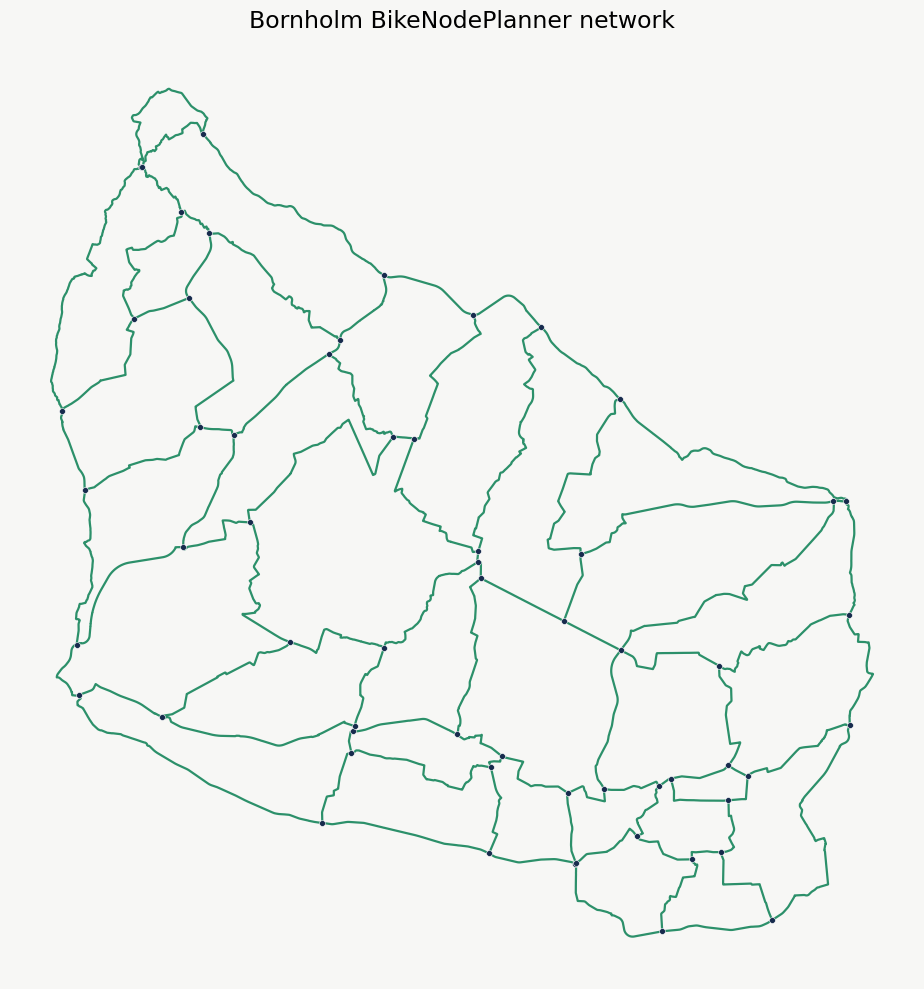

In [36]:
# Install once if needed:
# %pip install python-igraph geopandas matplotlib shapely

from pathlib import Path
import lzma
import pickle

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point


# -----------------------------
# Settings
# -----------------------------

GRAPH_PATH = Path(
    "/Users/ellenebdrup/Documents/GitHub/bike_safety/"
    "bikenwloops/data/processed/bornholm/network_preprocessed0.xz"
)

CRS = "EPSG:25832"

# Offset applied by the original study for its combined Denmark map.
STORED_OFFSET = (-220_000, 120_000)
UNDO_STUDY_OFFSET = True


# -----------------------------
# Load the igraph network
# -----------------------------

with lzma.open(GRAPH_PATH, "rb") as file:
    graph = pickle.load(file)

print(graph.summary())
print("Directed:", graph.is_directed())


# -----------------------------
# Convert edges to GeoDataFrame
# -----------------------------

edge_records = []

for edge in graph.es:
    attributes = edge.attributes().copy()
    attributes["source"], attributes["target"] = edge.tuple
    edge_records.append(attributes)

edges = gpd.GeoDataFrame(
    edge_records,
    geometry="geometry",
    crs=CRS,
)

edges = edges.loc[
    edges.geometry.notna() & ~edges.geometry.is_empty
].copy()


# -----------------------------
# Convert nodes to GeoDataFrame
# -----------------------------

node_records = []

for vertex in graph.vs:
    attributes = vertex.attributes().copy()

    node_records.append(
        {
            **attributes,
            "igraph_index": vertex.index,
            "geometry": Point(attributes["x"], attributes["y"]),
        }
    )

nodes = gpd.GeoDataFrame(
    node_records,
    geometry="geometry",
    crs=CRS,
)


# -----------------------------
# Restore Bornholm's real position
# -----------------------------

if UNDO_STUDY_OFFSET:
    undo_x = -STORED_OFFSET[0]  # +220,000 metres
    undo_y = -STORED_OFFSET[1]  # -120,000 metres

    edges["geometry"] = edges.geometry.translate(
        xoff=undo_x,
        yoff=undo_y,
    )

    nodes["geometry"] = nodes.geometry.translate(
        xoff=undo_x,
        yoff=undo_y,
    )


# -----------------------------
# Plot the network
# -----------------------------

fig, ax = plt.subplots(
    figsize=(10, 10),
    facecolor="#f7f7f5",
)

edges.plot(
    ax=ax,
    color="#16855b",
    linewidth=1.6,
    alpha=0.9,
    zorder=1,
)

nodes.plot(
    ax=ax,
    color="#172b4d",
    edgecolor="white",
    linewidth=0.4,
    markersize=18,
    zorder=2,
)

ax.set_title(
    "Bornholm BikeNodePlanner network",
    fontsize=17,
    pad=14,
)

ax.set_axis_off()
ax.set_aspect("equal")

fig.tight_layout()

# Optional export:
fig.savefig(
    "bornholm_bikenodeplanner_network.png",
    dpi=240,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

plt.show()